In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [16]:
df = pd.read_csv('./steam_games_dataset.csv')
df.head()

,appid,name,developer,publisher,score_rank,positive,negative,userscore,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
0,730,Counter-Strike: Global Offensive,Valve,Valve,NaN,7642084,1173003,0,"100,000,000 .. 200,000,000",33852,708,6645,301,0,0,0,1013936
1,1172470,Apex Legends,Respawn,Electronic Arts,NaN,668053,326926,0,"100,000,000 .. 200,000,000",10506,496,935,246,0,0,0,124262
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",NaN,1520457,1037487,0,"100,000,000 .. 200,000,000",23165,717,5622,261,0,0,0,314682
3,1623730,Palworld,Pocketpair,Pocketpair,NaN,358266,22443,0,"50,000,000 .. 100,000,000",3854,835,2213,257,2999,2999,0,18028
4,440,Team Fortress 2,Valve,Valve,NaN,1044264,117208,0,"50,000,000 .. 100,000,000",21244,736,4262,102,0,0,0,43819


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   appid            10000 non-null  int64  
 1   name             10000 non-null  str    
 2   developer        9967 non-null   str    
 3   publisher        9946 non-null   str    
 4   score_rank       5 non-null      float64
 5   positive         10000 non-null  int64  
 6   negative         10000 non-null  int64  
 7   userscore        10000 non-null  int64  
 8   owners           10000 non-null  str    
 9   average_forever  10000 non-null  int64  
 10  average_2weeks   10000 non-null  int64  
 11  median_forever   10000 non-null  int64  
 12  median_2weeks    10000 non-null  int64  
 13  price            10000 non-null  int64  
 14  initialprice     10000 non-null  int64  
 15  discount         10000 non-null  int64  
 16  ccu              10000 non-null  int64  
dtypes: float64(1), int64(12)

In [18]:
# Создадим столбец - разобьем owners на owners_low, owners_high

In [19]:
df["owners_low"] = pd.Series([0] * len(df), dtype="Int64")
df["owners_high"] = pd.Series([0] * len(df), dtype="Int64")
for i, val in enumerate(df.owners):
    df.at[i, "owners_low"], df.at[i, "owners_high"] = list(map(int, val.replace(',', '').split(' .. ')))

df.drop('owners', axis=1, inplace=True)
df.head()

,appid,name,developer,publisher,score_rank,positive,negative,userscore,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu,owners_low,owners_high
0,730,Counter-Strike: Global Offensive,Valve,Valve,NaN,7642084,1173003,0,33852,708,6645,301,0,0,0,1013936,100000000,200000000
1,1172470,Apex Legends,Respawn,Electronic Arts,NaN,668053,326926,0,10506,496,935,246,0,0,0,124262,100000000,200000000
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",NaN,1520457,1037487,0,23165,717,5622,261,0,0,0,314682,100000000,200000000
3,1623730,Palworld,Pocketpair,Pocketpair,NaN,358266,22443,0,3854,835,2213,257,2999,2999,0,18028,50000000,100000000
4,440,Team Fortress 2,Valve,Valve,NaN,1044264,117208,0,21244,736,4262,102,0,0,0,43819,50000000,100000000


In [20]:
# Слишком много NaN -> удалим столбец
df[df.score_rank.isnull()].shape
df.drop('score_rank', axis=1, inplace=True)

In [21]:
# Добавление строки

In [22]:
new_row = {col: np.nan for col in df.columns}
new_row = {
    'appid': 1,
    'name': "test",
    'developer': "me",
    'publisher': "me",
    'positive': 2000,
    'negative': 0,
    'userscore': 100,
    'average_forever': 1000,
    'average_2weeks': 10000,
    'median_forever': 4000,
    'median_2weeks': 8000,
    'price': 999,
    'initialprice': 2,
    'discount': 99,
    'ccu': 30000,
    'owners_low': 10000,
    'owners_high': 20000
}

df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
df.tail()

,appid,name,developer,publisher,positive,negative,userscore,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu,owners_low,owners_high
9996,649600,Swords and Sandals 2 Redux,Whiskeybarrel Studios,eGames.com,429,117,0,333,0,432,0,999,999,0,4,50000,100000
9997,1122120,STATIONflow,DMM GAMES,DMM GAMES,414,66,0,984,0,984,0,1799,1799,0,6,50000,100000
9998,424640,Karaski: What Goes Up...,Unbound Creations,Unbound Creations,51,8,0,0,0,0,0,1199,1199,0,0,50000,100000
9999,598060,Slasher's Keep,Damian Schloter,Damian Schloter,1791,355,0,423,0,396,0,1399,1399,0,6,50000,100000
10000,1,test,me,me,2000,0,100,1000,10000,4000,8000,999,2,99,30000,10000,20000


In [23]:
df = df[df["name"] != "test"].copy()

In [24]:
# Удалим строки с бесплатными играми
df = df[df["price"] > 0].copy()

In [25]:
# Удалим дубликаты по appid
df.drop_duplicates(subset=['appid'], inplace=True)

In [26]:
df['appid'].unique

<bound method Series.unique of 3       1623730
5       1938090
6       1063730
7       2358720
9           550
         ...   
9995     444720
9996     649600
9997    1122120
9998     424640
9999     598060
Name: appid, Length: 7889, dtype: int64>

In [27]:
# Самые дорогие приложения steam
df.sort_values('price', ascending=False).head()

,appid,name,developer,publisher,positive,negative,userscore,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu,owners_low,owners_high
4836,1325400,VEGAS Pro 18 Edit Steam Edition,MAGIX Software GmbH,MAGIX Software GmbH,478,1859,0,6020,0,6020,0,14999,14999,0,23,200000,500000
7176,279280,Ohmicide,Ohm Force,Ohm Force,1,1,0,0,0,0,0,12499,12499,0,0,100000,200000
4579,248170,Clickteam Fusion 2.5,Clickteam,Clickteam,1661,203,0,5745,150,238,150,9999,9999,0,134,200000,500000
8603,837510,Pixel Game Maker MV,"Gotcha Gotcha Games, KADOKAWA",Gotcha Gotcha Games,399,176,0,311,0,379,0,8499,8499,0,31,100000,200000
8996,741390,最強の囲碁 ～名人への道～ / Igo Meijin,UNBALANCE Corporation,UNBALANCE Corporation,3,1,0,0,0,0,0,7999,7999,0,1,100000,200000


## Визуализация

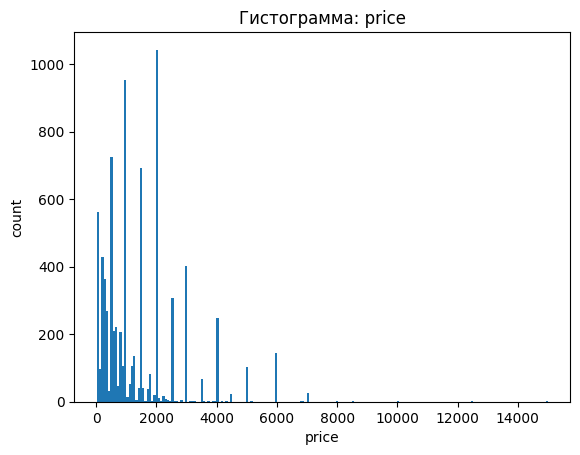

In [30]:
plt.hist(df.price, bins=200)
plt.title("Гистограмма: price")
plt.xlabel("price")
plt.ylabel("count")
plt.show()

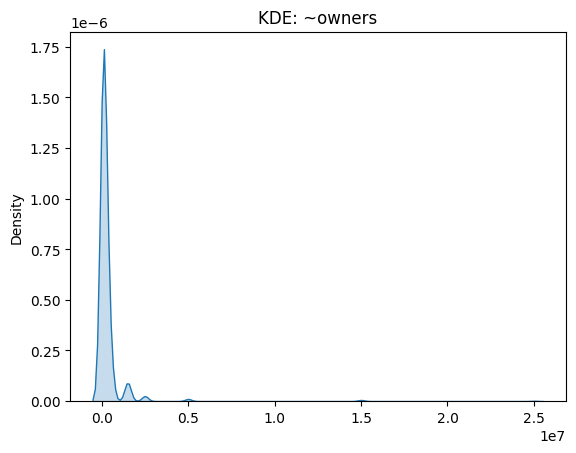

In [35]:
sns.kdeplot((df.owners_high - df.owners_low) / 2, fill=True)
plt.title("KDE: ~owners")
plt.show()

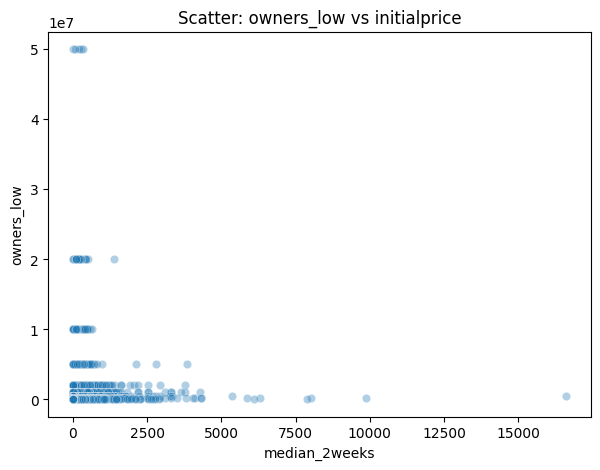

In [40]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="median_2weeks", y="owners_low", alpha=0.35)
plt.title("Scatter: owners_low vs initialprice")
plt.show()

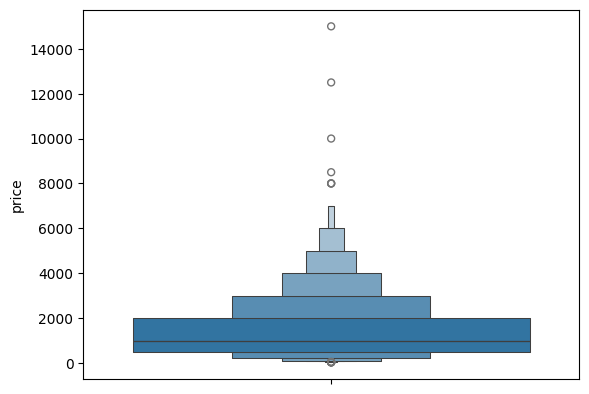

In [52]:
sns.boxenplot(data=df.price)
plt.xticks(rotation=90)
plt.show()